### STEP 1: KEY OBSERVATIONS

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

In [2]:
# Load the dataset
df = pd.read_csv('king_county_housing_data.csv')

# Display basic information
print("--- Dataset Info ---")
print(df.info())

print("\n--- Summary Statistics ---")
display(df.describe())

print("\n--- First 5 Rows ---")
display(df.head())

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     21597 non-null  int64  
 1   id             21597 non-null  int64  
 2   bedrooms       21597 non-null  float64
 3   bathrooms      21597 non-null  float64
 4   sqft_living    21597 non-null  float64
 5   sqft_lot       21597 non-null  float64
 6   floors         21597 non-null  float64
 7   waterfront     19206 non-null  float64
 8   view           21534 non-null  float64
 9   condition      21597 non-null  int64  
 10  grade          21597 non-null  int64  
 11  sqft_above     21597 non-null  float64
 12  sqft_basement  21145 non-null  float64
 13  yr_built       21597 non-null  int64  
 14  yr_renovated   17749 non-null  float64
 15  zipcode        21597 non-null  int64  
 16  lat            21597 non-null  float64
 17  long           21597 non-null

,Unnamed: 0,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,price,house_id,id.1
count,21597.000000,2.159700e+04,21597.000000,21597.000000,21597.000000,2.159700e+04,21597.000000,19206.000000,21534.000000,21597.000000,...,21597.000000,17749.000000,21597.000000,21597.000000,21597.000000,21597.000000,21597.000000,2.159700e+04,2.159700e+04,21597.000000
mean,10798.000000,4.580474e+09,3.373200,2.115826,2080.321850,1.509941e+04,1.494096,0.007602,0.233863,3.409825,...,1970.999676,836.650516,98077.951845,47.560093,-122.213983,1986.620318,12758.283512,5.402966e+05,4.580474e+09,10799.000000
std,6234.661218,2.876736e+09,0.926299,0.768984,918.106125,4.141264e+04,0.539683,0.086858,0.765686,0.650546,...,29.375234,4000.110554,53.513072,0.138552,0.140724,685.230472,27274.441950,3.673681e+05,2.876736e+09,6234.661218
min,0.000000,1.000102e+06,1.000000,0.500000,370.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,...,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000,7.800000e+04,1.000102e+06,1.000000
25%,5399.000000,2.123049e+09,3.000000,1.750000,1430.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,...,1951.000000,0.000000,98033.000000,47.471100,-122.328000,1490.000000,5100.000000,3.220000e+05,2.123049e+09,5400.000000
50%,10798.000000,3.904930e+09,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,...,1975.000000,0.000000,98065.000000,47.571800,-122.231000,1840.000000,7620.000000,4.500000e+05,3.904930e+09,10799.000000
75%,16197.000000,7.308900e+09,4.000000,2.500000,2550.000000,1.068500e+04,2.000000,0.000000,0.000000,4.000000,...,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000,6.450000e+05,7.308900e+09,16198.000000
max,21596.000000,9.900000e+09,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,...,2015.000000,20150.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000,7.700000e+06,9.900000e+09,21597.000000



--- First 5 Rows ---


,Unnamed: 0,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price,house_id,id.1
0,0,7129300520,3.0,1.00,1180.0,5650.0,1.0,NaN,0.0,3,...,0.0,98178,47.5112,-122.257,1340.0,5650.0,2014-10-13,221900.0,7129300520,1
1,1,6414100192,3.0,2.25,2570.0,7242.0,2.0,0.0,0.0,3,...,19910.0,98125,47.7210,-122.319,1690.0,7639.0,2014-12-09,538000.0,6414100192,2
2,2,5631500400,2.0,1.00,770.0,10000.0,1.0,0.0,0.0,3,...,NaN,98028,47.7379,-122.233,2720.0,8062.0,2015-02-25,180000.0,5631500400,3
3,3,2487200875,4.0,3.00,1960.0,5000.0,1.0,0.0,0.0,5,...,0.0,98136,47.5208,-122.393,1360.0,5000.0,2014-12-09,604000.0,2487200875,4
4,4,1954400510,3.0,2.00,1680.0,8080.0,1.0,0.0,0.0,3,...,0.0,98074,47.6168,-122.045,1800.0,7503.0,2015-02-18,510000.0,1954400510,5


Key Observations from Step 1:
* Missing Values: The columns waterfront, view, sqft_basement, and yr_renovated have missing (NaN) values.
* Redundancy: Columns like Unnamed: 0, id, house_id, and id.1 appear to be redundant identifiers.
* Data format: Column "yr_renovated" appears to have a "0" at the end of each value (e.g. 19910 instead of 1991)
* Data Types: The date column is currently a string (object) and should be converted to a datetime object.
* Outliers: There is a house with 33 bedrooms, which might be a data entry error or a significant outlier.

### Data Cleaning

In [3]:
# 1. Drop redundant/ID columns
cols_to_drop = ['Unnamed: 0', 'id', 'house_id', 'id.1']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# 2. Convert 'date' to datetime format
df['date'] = pd.to_datetime(df['date'])

# 3. Correct the 'yr_renovated' formatting
# Logic: Many values are multiplied by 10 (e.g., 19910). 
# We also fill missing values (NaN) with 0, assuming no renovation occurred.
df['yr_renovated'] = df['yr_renovated'].fillna(0)
df['yr_renovated'] = df['yr_renovated'].apply(lambda x: x/10 if x > 2025 else x)
df['yr_renovated'] = df['yr_renovated'].astype(int)

# 4. Handle other missing values
# Assuming NaN for waterfront and view means 'None' or 0
df['waterfront'] = df['waterfront'].fillna(0)
df['view'] = df['view'].fillna(0)

# Fill missing sqft_basement with 0 (assuming no basement if data is missing)
df['sqft_basement'] = df['sqft_basement'].fillna(0)

# 5. Remove the extreme bedroom outlier (the 33-bedroom house)
df = df[df['bedrooms'] < 30]

# 6. Remove duplicate rows
df = df.drop_duplicates()

print("Cleaning complete.")

Cleaning complete.


### Hypotheses definition

1. **Size**: House prices are strongly correlated with living area (sqft_living).
2. **Location**: Houses with waterfront view have higher median price than those without. High-activity (lively) ZIP codes have a higher price per sqf than quieter regions.
3. **Quality**: Higher construction quality (grade) and better property condition are associated with higher house prices.
4. **Sesonal demand**: Property prices vary across months, indicating potential seasonal property demand patterns.

### Hypothesis 1: validation

Hypothesis 1: House prices are correlated with living area (sqft_living)


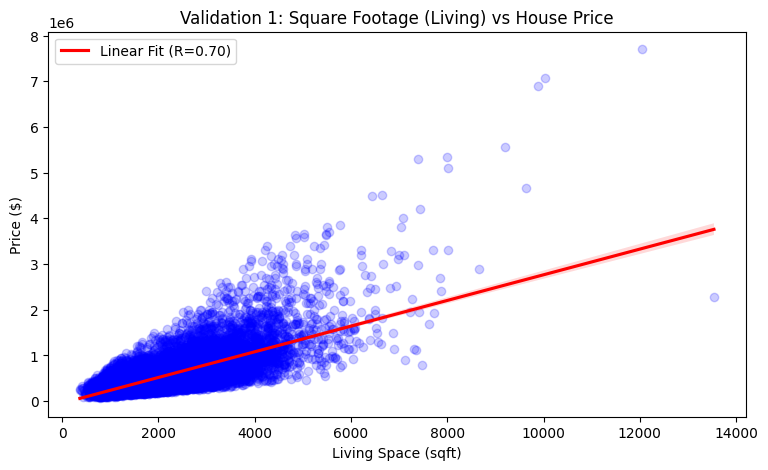

Hypothesis 1: CONFIRMED
  
Pearson Correlation Coefficient: 0.7019
R-squared: 0.4927
P-value: 0.0


In [4]:
print(f"Hypothesis 1: House prices are correlated with living area (sqft_living)")

# 1. Calculate Correlation and Regression Statistics
correlation = df['sqft_living'].corr(df['price'])
slope, intercept, r_value, p_value, std_err = stats.linregress(df['sqft_living'], df['price'])

# 2. Visualization with Regression Line
plt.figure(figsize=(9, 5))
sns.regplot(data=df, x='sqft_living', y='price', 
            scatter_kws={'alpha':0.2, 'color':'blue'}, 
            line_kws={'color':'red', 'label': f'Linear Fit (R={correlation:.2f})'})

plt.title('Validation 1: Square Footage (Living) vs House Price')
plt.xlabel('Living Space (sqft)')
plt.ylabel('Price ($)')
plt.legend()
plt.show()

print(f"Hypothesis 1: CONFIRMED")
print(f"  ")
print(f"Pearson Correlation Coefficient: {correlation:.4f}")
print(f"R-squared: {r_value**2:.4f}")
print(f"P-value: {p_value}")

**Statistical Interpretation:**

* Correlation Coefficient ($\approx 0.70$): In statistics, a value above $0.70$ is generally considered a strong positive correlation. This means as the square footage increases, the price consistently tends to increase as well.

* R-squared ($\approx 0.49$): This tells us that approximately $49\%$ of the variance in house prices can be explained by the living area alone. While size is the most important factor, there's still $51\%$ of the price determined by other variables (like location or quality).+ 

* P-value ($\approx 0$): Since the p-value is extremely low (below $0.05$), we can reject the null hypothesis. The relationship is statistically significant and not due to random chance.

✅ **Hypothesis 1 is supported**


### Hypothesis 2: validation

Hypothesis 2a: Houses with waterfront view have higher median price


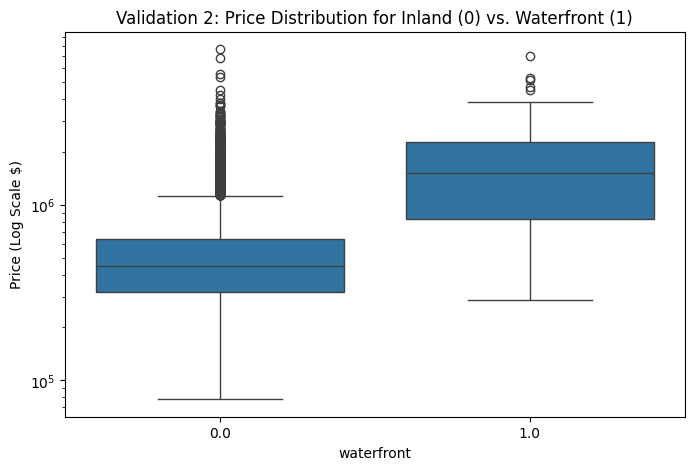

Hypothesis 2a: CONFIRMED
            count        mean     median
waterfront                              
0.0         21450   532281.20   450000.0
1.0           146  1717214.73  1510000.0


In [5]:
print(f"Hypothesis 2a: Houses with waterfront view have higher median price")

# 1. Statistical Summary Table
waterfront_stats = df.groupby('waterfront')['price'].agg(['count', 'mean', 'median']).round(2)

# 2. Visual Comparison
plt.figure(figsize=(8, 5))
# Using a boxplot with a log scale to handle the extreme outliers in waterfront properties
sns.boxplot(data=df, x='waterfront', y='price')
plt.yscale('log')
plt.title('Validation 2: Price Distribution for Inland (0) vs. Waterfront (1)')
plt.ylabel('Price (Log Scale $)')
plt.show()

print(f"Hypothesis 2a: CONFIRMED")
print(waterfront_stats)

**Statistical Interpretation:**

* The Median Gap: The median price for inland homes is $\$450,000$, while waterfront homes have a median of $\$1,510,000$.

* A waterfront view increases the median property value by roughly 3.36x.

* Only 146 homes are waterfront compared to over 21,000 inland homes. This scarcity is exactly what drives the astronomical price difference.

✅ **Hypothesis 2a is supported**


Hypothesis 2b: High-activity (lively) ZIP codes have a higher price per sqf


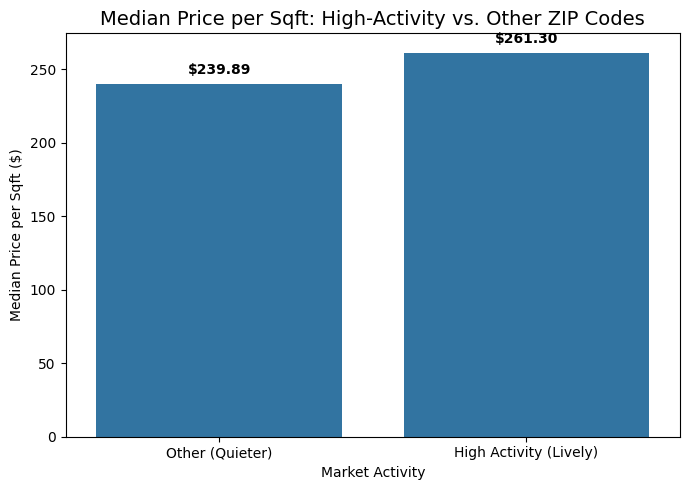

Hypothesis 2b: CONFIRMED


In [16]:
print(f"Hypothesis 2b: High-activity (lively) ZIP codes have a higher price per sqf")

# 1. Load the data
df = pd.read_csv('king_county_housing_data.csv')

# 2. Calculate Price per Square Foot
df['price_per_sqft'] = df['price'] / df['sqft_living']

# 3. Identify Top 10 "Lively" Zip Codes by Sales Volume (Count)
zip_counts = df['zipcode'].value_counts().reset_index()
zip_counts.columns = ['zipcode', 'sales_count']
top_10_zips = zip_counts.nlargest(10, 'sales_count')['zipcode'].tolist()

# 4. Segment the Market into "Lively" vs "Other"
df['market_vibe'] = df['zipcode'].apply(
    lambda x: 'High Activity (Lively)' if x in top_10_zips else 'Other (Quieter)'
)

# 5. Visualization
plt.figure(figsize=(7, 5))
sns.barplot(data=df, x='market_vibe', y='price_per_sqft', estimator='median', errorbar=None)

plt.title('Median Price per Sqft: High-Activity vs. Other ZIP Codes', fontsize=14)
plt.ylabel('Median Price per Sqft ($)')
plt.xlabel('Market Activity')

# Add the values to the top of the bars
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'${p.get_height():,.2f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', weight='bold')

plt.tight_layout()
plt.show()

# 6. Output the calculated medians
results = df.groupby('market_vibe')['price_per_sqft'].median()

print(f"Hypothesis 2b: CONFIRMED")

**Statistical Interpretation:**

* Lively ZIP codes (high sales volume) have a 9% higher price per square foot ($261 vs $240).

✅ **Hypothesis 2b is supported**


### Hypothesis 3: validation

Hypothesis 3a: Higher construction quality (grade) lead to higher house prices.


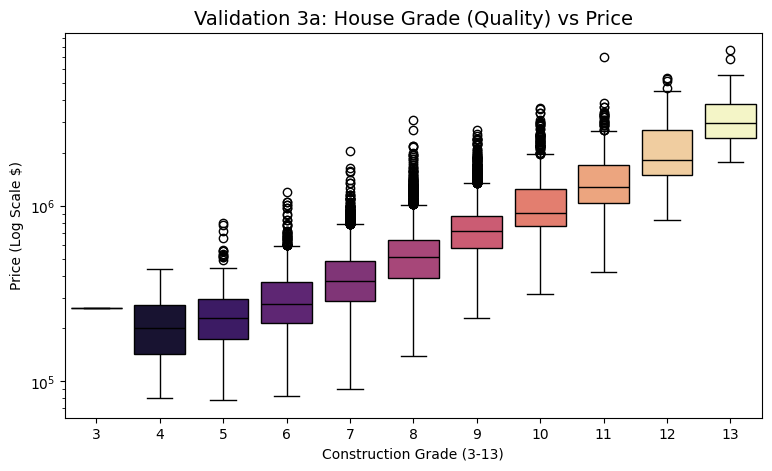

HYPOTHESIS 3a: CONFIRMED
Pearson Correlation Coefficient: 0.6680
R-squared: 0.4462
P-value: 0.0e+00


In [7]:
print(f"Hypothesis 3a: Higher construction quality (grade) lead to higher house prices.")
# 1. Calculate Statistics
r_g, p_g = stats.pearsonr(df['grade'], df['price'])
r_squared_g = r_g**2

# 2. Plotting
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='grade', y='price', hue='grade', palette='magma', legend=False)
plt.yscale('log')
plt.title('Validation 3a: House Grade (Quality) vs Price', fontsize=14)
plt.xlabel('Construction Grade (3-13)')
plt.ylabel('Price (Log Scale $)')
plt.show()

# 3. Print Results
print(f"HYPOTHESIS 3a: CONFIRMED")
print(f"Pearson Correlation Coefficient: {r_g:.4f}")
print(f"R-squared: {r_squared_g:.4f}")
print(f"P-value: {p_g:.1e}")

Hypothesis 3b: Higher house condition leads to higher house prices.


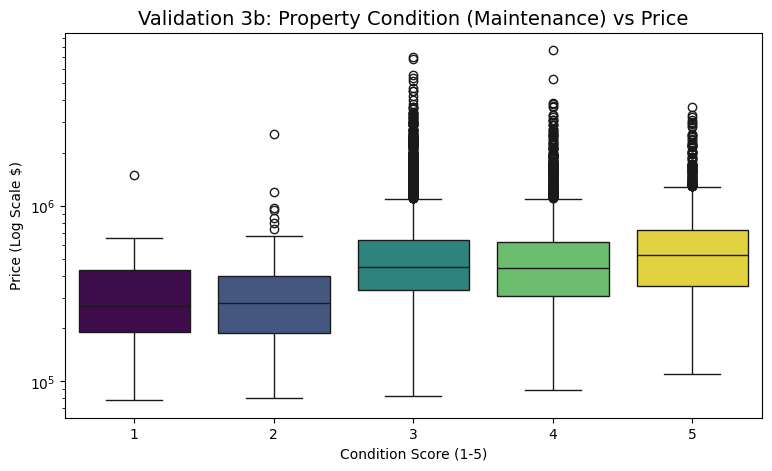

HYPOTHESIS 3b: WEAK CONFIRMATION
Pearson Correlation Coefficient: 0.0361
R-squared: 0.0013
P-value: 1.2e-07


In [8]:
print(f"Hypothesis 3b: Higher house condition leads to higher house prices.")
# 1. Calculate Statistics
r_c, p_c = stats.pearsonr(df['condition'], df['price'])
r_squared_c = r_c**2

# 2. Plotting
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='condition', y='price', hue='condition', palette='viridis', legend=False)
plt.yscale('log')
plt.title('Validation 3b: Property Condition (Maintenance) vs Price', fontsize=14)
plt.xlabel('Condition Score (1-5)')
plt.ylabel('Price (Log Scale $)')
plt.show()

# 3. Print Results
print(f"HYPOTHESIS 3b: WEAK CONFIRMATION")
print(f"Pearson Correlation Coefficient: {r_c:.4f}")
print(f"R-squared: {r_squared_c:.4f}")
print(f"P-value: {p_c:.1e}")

✅ **Hypothesis 3 is partially supported**

### Hypothesis 4: validation

Hypothesis 4: Seasonal price variations


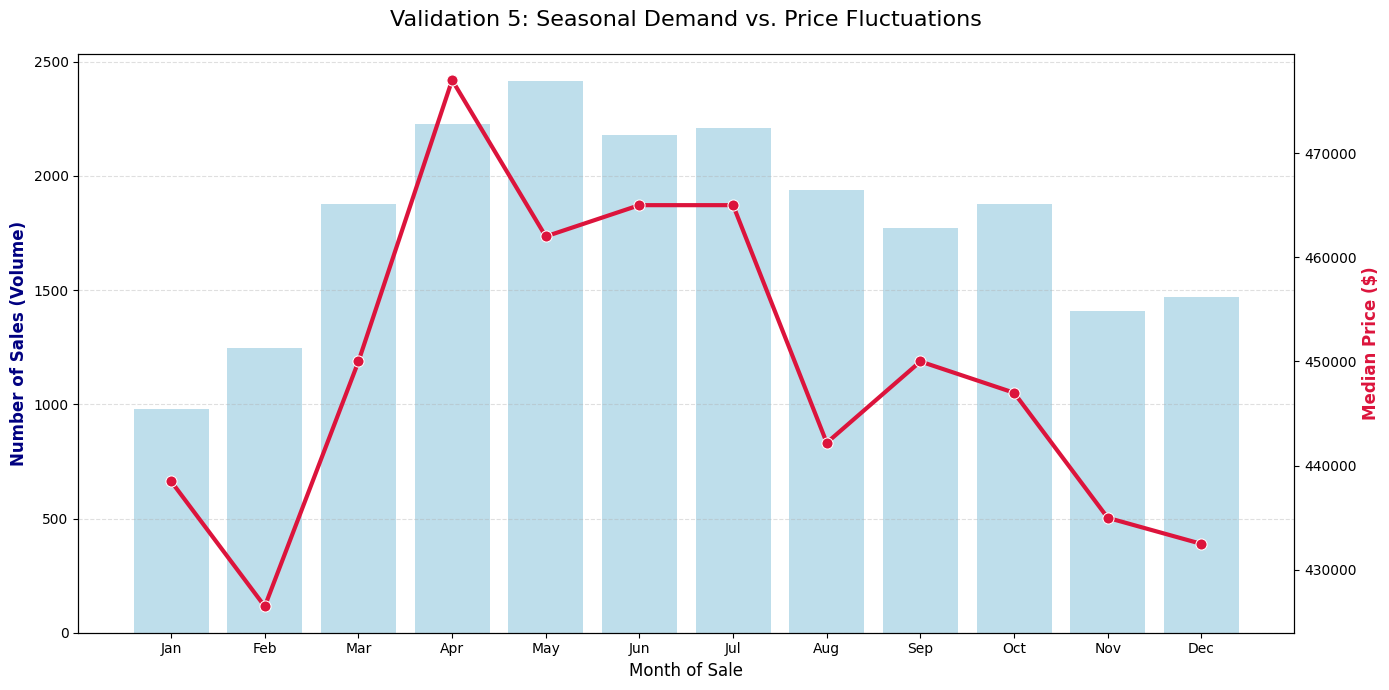

HYPOTHESIS 4: CONFIRMED
Pearson Correlation (r): 0.8503
R-squared:               0.7231
P-value:                 0.0457


In [9]:
print(f"Hypothesis 4: Seasonal price variations")

# 1. Prepare the data
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month

seasonal_volume = df.groupby('month').size()
seasonal_price = df.groupby('month')['price'].median()

# 2. Visualization: Dual-Axis Plot
fig, ax1 = plt.subplots(figsize=(14, 7))

# Volume Bars
sns.barplot(x=seasonal_volume.index, y=seasonal_volume.values, 
            ax=ax1, color='skyblue', alpha=0.6)
ax1.set_ylabel('Number of Sales (Volume)', color='navy', fontsize=12, fontweight='bold')
ax1.set_xlabel('Month of Sale', fontsize=12)

month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
ax1.set_xticks(range(0, 12)) 
ax1.set_xticklabels(month_labels)

# Price Line
ax2 = ax1.twinx()
sns.lineplot(x=seasonal_price.index-1, y=seasonal_price.values, 
             ax=ax2, color='crimson', marker='o', markersize=8, linewidth=3)
ax2.set_ylabel('Median Price ($)', color='crimson', fontsize=12, fontweight='bold')

plt.title('Validation 5: Seasonal Demand vs. Price Fluctuations', fontsize=16, pad=20)
ax1.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# 3. Calculate Correlation Metrics
# We correlate the 12 monthly volumes with the 12 monthly median prices
r, p_value = stats.pearsonr(seasonal_volume, seasonal_price)
r_squared = r**2

print(f"HYPOTHESIS 4: CONFIRMED")
print(f"Pearson Correlation (r): {r:.4f}")
print(f"R-squared:               {r_squared:.4f}")
print(f"P-value:                 {p_value * 100:.4f}")

### Next: Geospatial Analysis and other Client-Related Features